In [ ]:
pip install tensorflow[and-cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 72.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalli

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# New Section

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:08<00:00, 13.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1


In [ ]:
print(os.listdir(path))

['Brain Tumor Data Set', 'metadata_rgb_only.csv', 'metadata.csv']


In [ ]:
images_path=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Brain Tumor")
print(images_path)

/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor


In [ ]:
print(len(os.listdir(images_path)))
print(os.listdir(images_path)[:5])

2513
['Cancer (1672).jpg', 'Cancer (1718).jpg', 'Cancer (961).jpg', 'Cancer (1941).jpg', 'Cancer (2104).jpg']


In [ ]:
images_path1=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Healthy")
print(images_path)

/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor


In [ ]:
print(len(os.listdir(images_path1)))
print(os.listdir(images_path1)[:5])

2087
['Not Cancer  (1026).jpg', 'Not Cancer  (954).jpg', 'Not Cancer  (666).jpg', 'Not Cancer  (1294).jpg', 'Not Cancer  (1095).jpg']


In [ ]:
import os
from PIL import Image

# ✅ Correct source paths
tumor_src = os.path.join(path, "Brain Tumor Data Set", "Brain Tumor Data Set", "Brain Tumor")
healthy_src = os.path.join(path, "Brain Tumor Data Set", "Brain Tumor Data Set", "Healthy")

# ✅ Target paths
base_dir = "/kaggle/working/brain_dataset"
tumor_dir = os.path.join(base_dir, "tumor")
healthy_dir = os.path.join(base_dir, "healthy")

os.makedirs(tumor_dir, exist_ok=True)
os.makedirs(healthy_dir, exist_ok=True)

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif")

# 🔁 Function to clean + copy
def process_images(src, target):
    for file in os.listdir(src):

        file_path = os.path.join(src, file)

        if not file.lower().endswith(valid_ext):
            continue

        try:
            img = Image.open(file_path).convert("RGB")

            new_name = file.split(".")[0] + ".jpg"
            save_path = os.path.join(target, new_name)

            img.save(save_path, "JPEG")

        except:
            print("Skipped:", file)

# 🚀 Run for both classes
process_images(tumor_src, tumor_dir)
process_images(healthy_src, healthy_dir)

print("✅ Dataset ready")

✅ Dataset ready


In [ ]:
print("Tumor:", len(os.listdir(tumor_dir)))
print("Healthy:", len(os.listdir(healthy_dir)))

Tumor: 2426
Healthy: 2080


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

class_names = train_ds.class_names



Found 4506 files belonging to 2 classes.
Using 3605 files for training.
Found 4506 files belonging to 2 classes.
Using 901 files for validation.


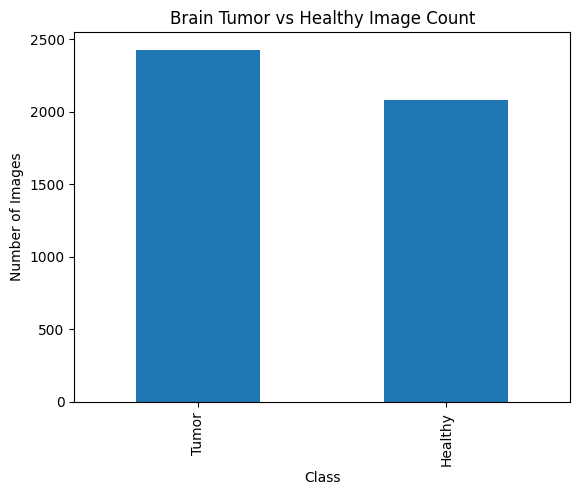

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# your dataset path
base_dir = "/kaggle/working/brain_dataset"

tumor_dir = os.path.join(base_dir, "tumor")
healthy_dir = os.path.join(base_dir, "healthy")

# count images
data = {
    "Class": ["Tumor", "Healthy"],
    "Count": [
        len(os.listdir(tumor_dir)),
        len(os.listdir(healthy_dir))
    ]
}

df = pd.DataFrame(data)

# plot (same style as your code)
plt.figure()
df.set_index("Class")["Count"].plot(kind='bar')

plt.title("Brain Tumor vs Healthy Image Count")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

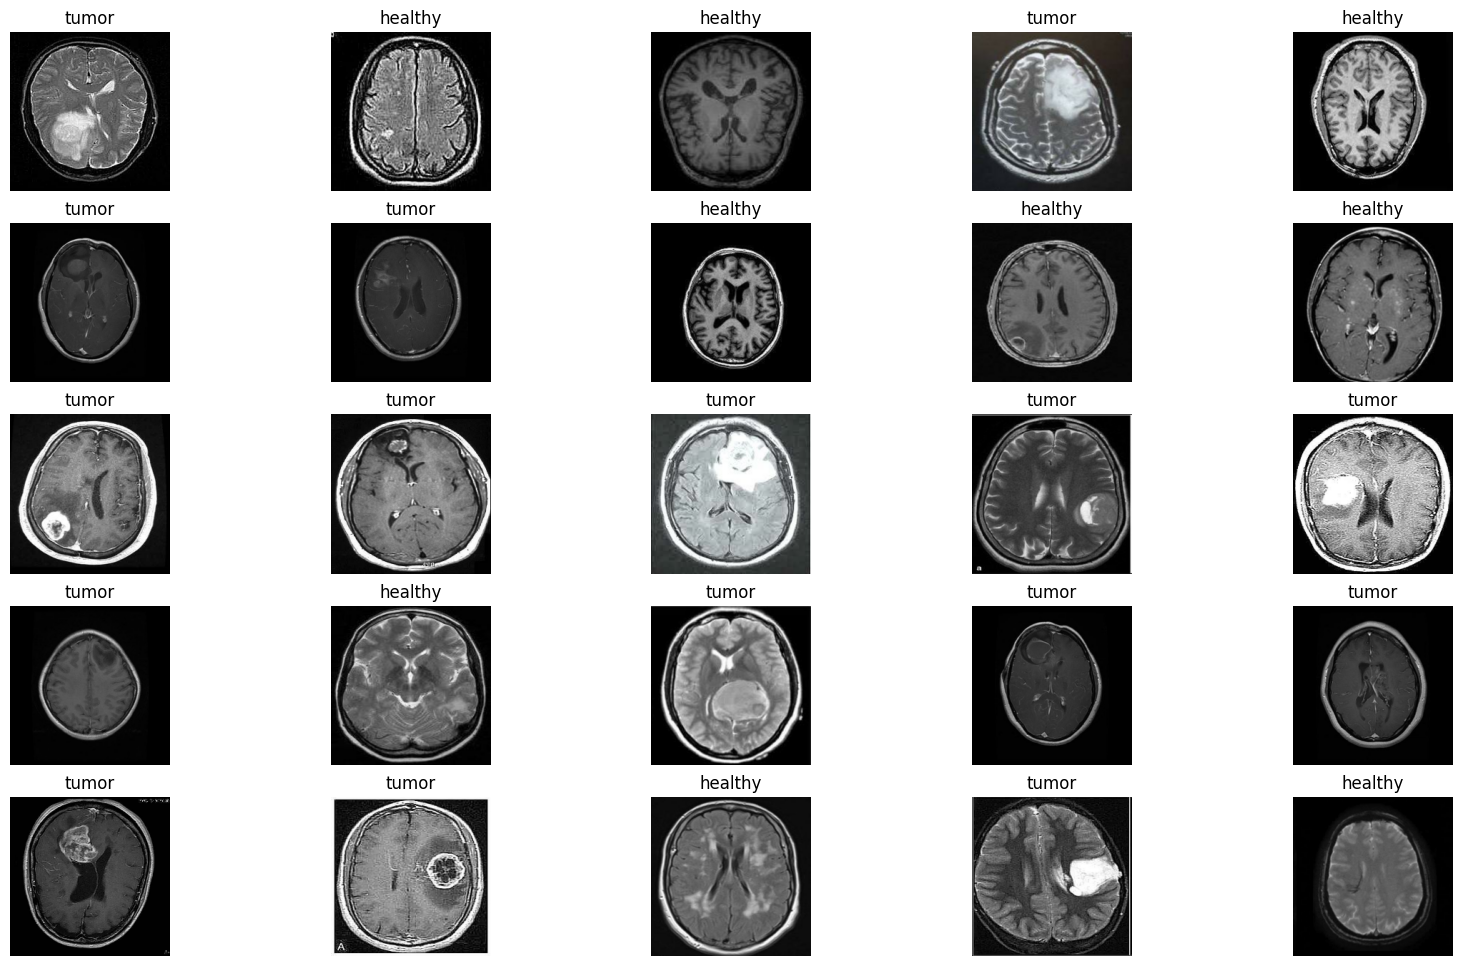

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,12))

for images, labels in train_ds.take(1):

    for i in range(25):

        plt.subplot(5,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()

In [ ]:
# ✅ Normalize AFTER creation
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds   = val_ds.map(lambda x, y: (x/255.0, y))

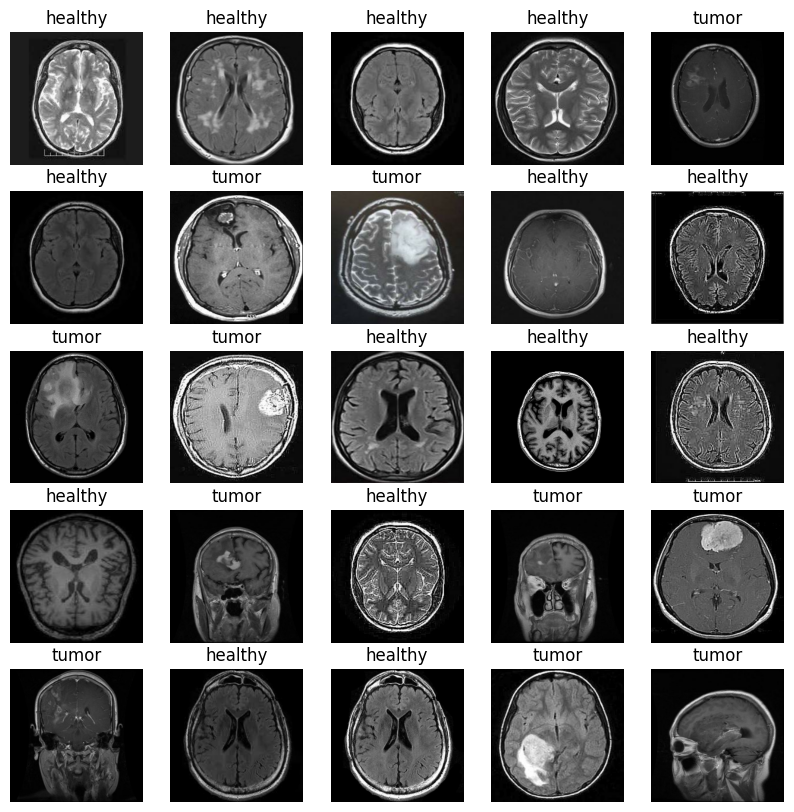

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(25):

        plt.subplot(5,5,i+1)

        plt.imshow((images[i].numpy()*255).astype("uint8"))

        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()


In [ ]:
import tensorflow as tf

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),   # small rotation
    tf.keras.layers.RandomZoom(0.05),       # slight zoom
    tf.keras.layers.RandomContrast(0.1)     # improve robustness
])

In [ ]:
from PIL import Image
import os

sizes = []

for folder in ["tumor", "healthy"]:
    folder_path = os.path.join(base_dir, folder)

    for file in os.listdir(folder_path)[:50]:
        img = Image.open(os.path.join(folder_path, file))
        sizes.append(img.size)

print("Sample image sizes:", sizes[:10])

Sample image sizes: [(630, 630), (276, 323), (310, 380), (279, 344), (231, 283), (175, 167), (512, 512), (250, 290), (276, 323), (450, 446)]


In [ ]:
from sklearn.utils import class_weight
import numpy as np

labels = []

for _, y in train_ds:
    labels.extend(y.numpy())

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.076762246117085), 1: np.float64(0.9334541688244433)}


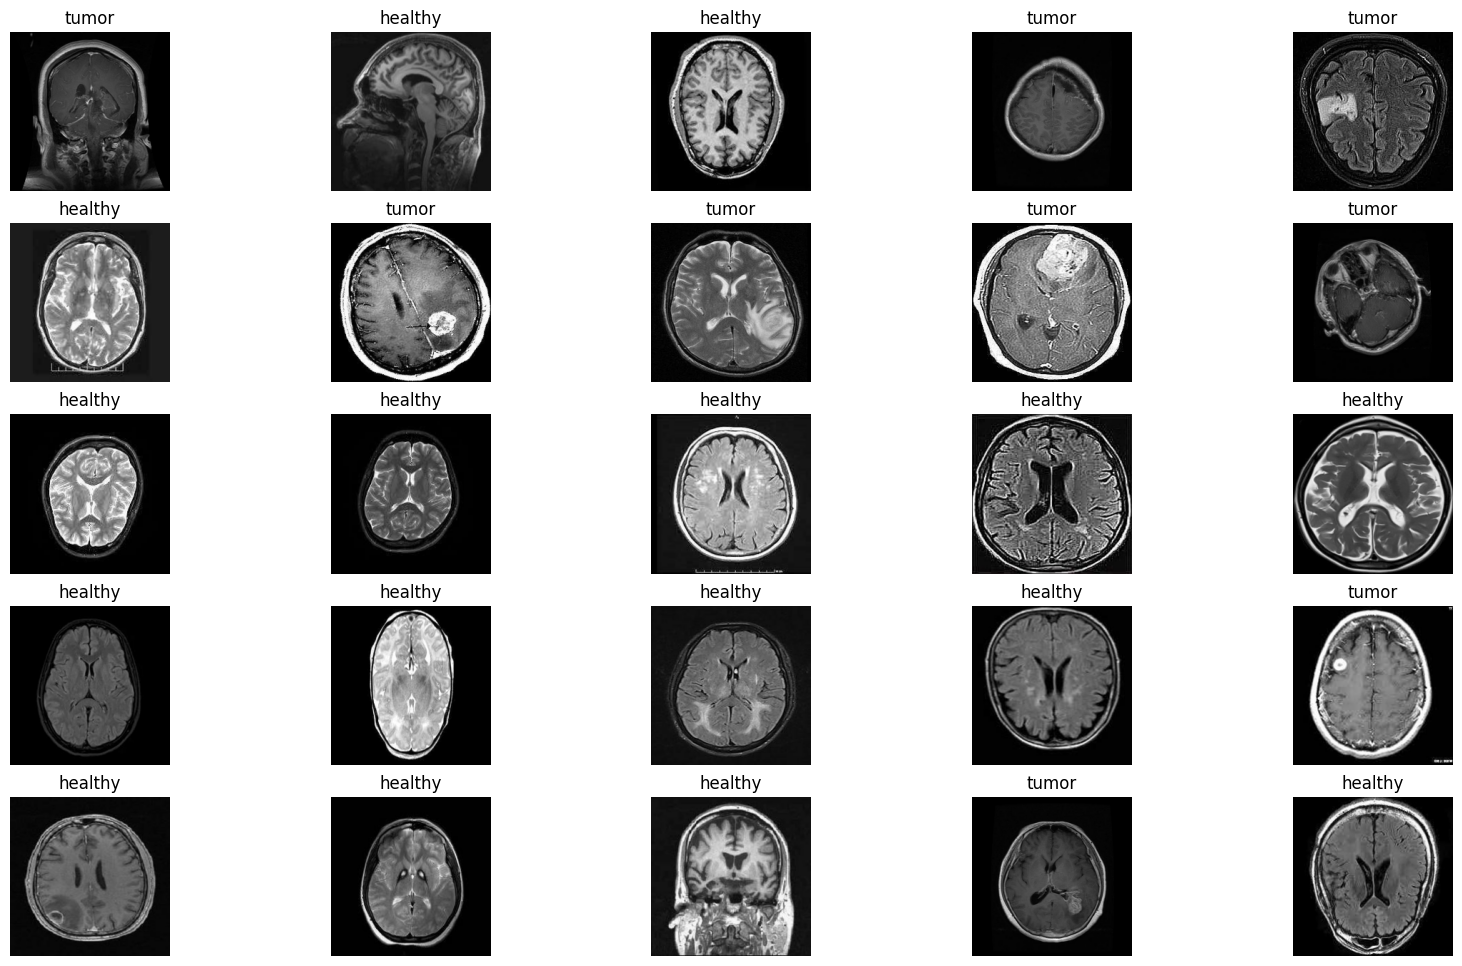

In [ ]:
plt.figure(figsize=(20,12))

for images, labels in train_ds.take(1):

    for i in range(25):

        plt.subplot(5,5,i+1)

        plt.imshow((images[i].numpy() * 255).astype("uint8"))

        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()

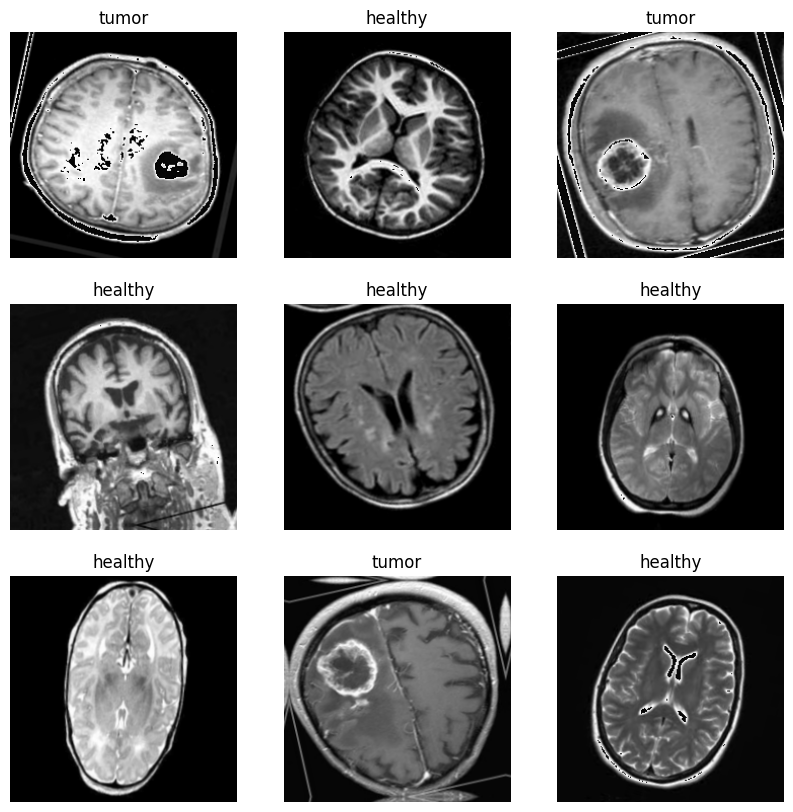

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    augmented_images = data_aug(images)   # ✅ APPLY AUGMENTATION

    for i in range(9):

        plt.subplot(3,3,i+1)

        # convert back if normalized
        plt.imshow((augmented_images[i].numpy() * 255).astype("uint8"))

        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()




In [ ]:
import tensorflow as tf

cnn_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224,224,3)),

    data_aug,

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),


    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # 🔹 Dense
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.7753 - loss: 0.6484 - val_accuracy: 0.5494 - val_loss: 1.1198
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.8574 - loss: 0.3252 - val_accuracy: 0.6027 - val_loss: 0.9340
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.8885 - loss: 0.2666 - val_accuracy: 0.7370 - val_loss: 0.6360
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.9085 - loss: 0.2203 - val_accuracy: 0.8380 - val_loss: 0.3704
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - accuracy: 0.9207 - loss: 0.2008 - val_accuracy: 0.9068 - val_loss: 0.2114
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - accuracy: 0.9348 - loss: 0.1576 - val_accuracy: 0.9567 - val_loss: 0.1236
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - accuracy: 0.9445 - loss: 0.1443 - val_accuracy: 0.9356 - val_loss: 0.1677
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 139ms/step - accuracy: 0.9542 - loss: 0

In [ ]:
import tensorflow as tf

# ✅ Load pretrained base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# ❄️ Freeze full model (IMPORTANT → gives stable accuracy)
base_model.trainable = False


# ✅ Build model (simple version)
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224,224,3)),

    data_aug,   # augmentation

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])




In [ ]:


# ✅ Compile (default adam works fine here)
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.8546 - loss: 0.3390 - val_accuracy: 0.9134 - val_loss: 0.2097
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.9179 - loss: 0.2141 - val_accuracy: 0.8923 - val_loss: 0.2416
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9362 - loss: 0.1694 - val_accuracy: 0.9256 - val_loss: 0.1748
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9473 - loss: 0.1461 - val_accuracy: 0.8979 - val_loss: 0.2325
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9545 - loss: 0.1317 - val_accuracy: 0.9345 - val_loss: 0.1609
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9567 - loss: 0.1204 - val_accuracy: 0.9223 - val_loss: 0.1764
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9637 - loss: 0.0962 - val_accuracy: 0.9134 - val_loss: 0.2108
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9603 - loss: 0.1043 - val_ac

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, test_ds, model_name="Model"):

    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images)
        preds = (preds > 0.5).astype(int)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.flatten())

    print(f"\n===== {model_name} Evaluation =====")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [ ]:
evaluate_model(cnn_model, val_ds, model_name="CNN Model")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 

In [ ]:
evaluate_model(mobilenet_model, val_ds, model_name="MobileNet Model")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


In [ ]:
cnn_model.save("cnn_model.h5")

In [ ]:
cnn_model.save("mobilenet_model.h5")